# DeepStock Predictor: PyTorch Time-Series Stock Forecasting
### Amazon (AMZN) Historical Stock Price Regression (2012–2024)
**Models:** LSTM (Long Short-Term Memory) vs. GRU (Gated Recurrent Unit) vs. Baselines  
**Framework:** PyTorch 2.x, Pandas, Scikit-Learn, Matplotlib  
🌐 **Live Interactive Web Dashboard:** [https://microsoft-deepstock-predictor-1lr4.vercel.app/](https://microsoft-deepstock-predictor-1lr4.vercel.app/)

## 1. Environment Setup & Import Dependencies
Setting seed for reproducibility and loading core deep learning & data libraries.

In [ ]:
import os
import sys
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Set random seed for reproducibility
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

plt.style.use('seaborn-v0_8-darkgrid' if 'seaborn-v0_8-darkgrid' in plt.style.available else 'default')
plt.rcParams['figure.dpi'] = 120
print(f'PyTorch Version: {torch.__version__}')
print(f'CUDA Available: {torch.cuda.is_available()}')

PyTorch Version: 2.13.0+cpu
CUDA Available: False


## 2. Historical Stock Data Acquisition & Preprocessing
Downloading Amazon (`AMZN`) daily stock prices from 2012 to 2024 via Yahoo Finance.

In [ ]:
# Download AMZN stock data (Jan 1, 2012 to Jan 1, 2024)
ticker = 'AMZN'
df = yf.download(ticker, start='2012-01-01', end='2024-01-01')

# Clean multi-index columns if present
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

df = df.reset_index()
print(f'Dataset shape: {df.shape}')
print(f'Date range: {df["Date"].min().strftime("%Y-%m-%d")} to {df["Date"].max().strftime("%Y-%m-%d")}')
print(f'Missing values: {df["Close"].isnull().sum()}')
df.head()

Dataset shape: (3018, 6)
Date range: 2012-01-03 to 2023-12-29
Missing values: 0


### 2.1 Visualizing Closing Price Timeline
Plotting historical daily closing prices to observe macro trends, bull runs, and market pullbacks over the 12-year window.

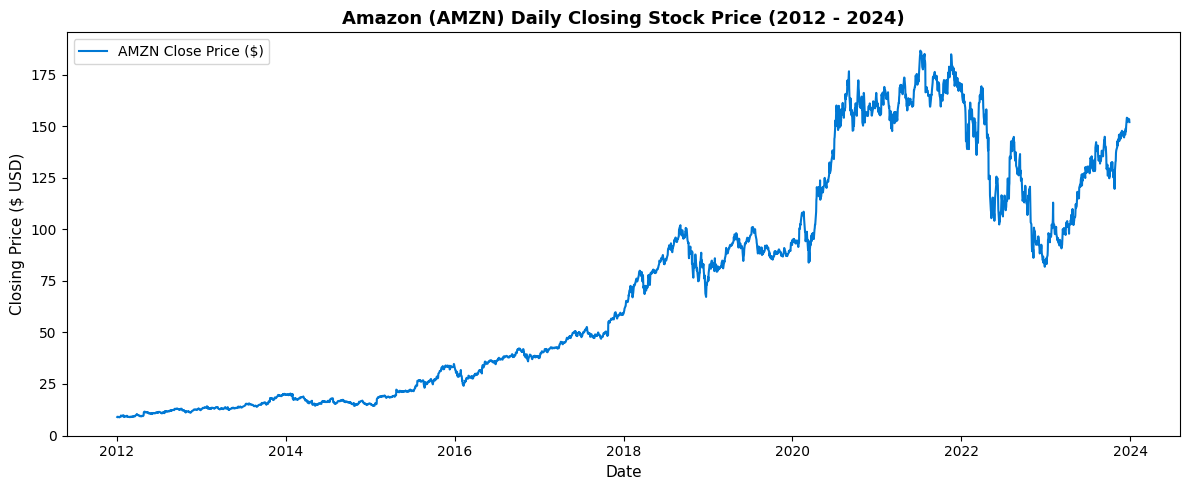

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(df['Date'], df['Close'], color='#0078D4', linewidth=1.5, label='AMZN Close Price ($)')
plt.title('Amazon (AMZN) Daily Closing Stock Price (2012 - 2024)', fontsize=13, fontweight='bold')
plt.xlabel('Date', fontsize=11)
plt.ylabel('Closing Price ($ USD)', fontsize=11)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

## 3. Data Normalization & Sliding Window Pipeline
Neural networks require bounded input values to prevent gradient explosion. We apply `MinMaxScaler(feature_range=(-1, 1))` to raw closing prices.

We structure input sequences using a sliding window approach:
- `lookback = 20` days (input features: $X_t = [p_{t-19}, p_{t-18}, \dots, p_t]$)
- Target label ($y_t = p_{t+1}$): prediction of day 21.

In [ ]:
lookback = 20
train_ratio = 0.8

# Fit scaler on closing price series
scaler = MinMaxScaler(feature_range=(-1, 1))
scaled_data = scaler.fit_transform(df[['Close']].values)

def create_sliding_windows(data, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i : i + window_size])
        y.append(data[i + window_size])
    return np.array(X), np.array(y)

X_all, y_all = create_sliding_windows(scaled_data, lookback)

# Chronological Train / Test Split (no random shuffle to prevent lookahead bias)
train_size = int(len(X_all) * train_ratio)

X_train_np, y_train_np = X_all[:train_size], y_all[:train_size]
X_test_np, y_test_np = X_all[train_size:], y_all[train_size:]

# Convert to PyTorch Tensors
X_train = torch.tensor(X_train_np, dtype=torch.float32)
y_train = torch.tensor(y_train_np, dtype=torch.float32)
X_test = torch.tensor(X_test_np, dtype=torch.float32)
y_test = torch.tensor(y_test_np, dtype=torch.float32)

print(f'X_train shape: {X_train.shape} | y_train shape: {y_train.shape}')
print(f'X_test shape:  {X_test.shape}  | y_test shape:  {y_test.shape}')

X_train shape: torch.Size([2398, 20, 1]) | y_train shape: torch.Size([2398, 1])
X_test shape:  torch.Size([600, 20, 1])  | y_test shape:  torch.Size([600, 1])


## 4. PyTorch Model Architectures (LSTM & GRU)
Defining recurrent neural network architectures inheriting from `torch.nn.Module`.

1. **LSTM (Long Short-Term Memory):** Uses cell state $c_t$ alongside hidden state $h_t$ with input, forget, and output gates.
2. **GRU (Gated Recurrent Unit):** Uses update and reset gates, combining memory cell into a single state for computational efficiency.

In [ ]:
class LSTMModel(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=32, num_layers=2, output_dim=1, dropout=0.2):
        super(LSTMModel, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.fc = nn.Linear(hidden_dim, output_dim)
        
    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)
        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])
        return out

class GRUModel(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=32, num_layers=2, output_dim=1, dropout=0.2):
        super(GRUModel, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        
        self.gru = nn.GRU(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.fc = nn.Linear(hidden_dim, output_dim)
        
    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)
        out, _ = self.gru(x, h0)
        out = self.fc(out[:, -1, :])
        return out

lstm_model = LSTMModel(input_dim=1, hidden_dim=32, num_layers=2)
gru_model = GRUModel(input_dim=1, hidden_dim=32, num_layers=2)

print('LSTM Trainable Parameters:', sum(p.numel() for p in lstm_model.parameters() if p.requires_grad))
print('GRU Trainable Parameters: ', sum(p.numel() for p in gru_model.parameters() if p.requires_grad))

LSTM Trainable Parameters: 12961
GRU Trainable Parameters:  9729


## 5. Model Training & Loss Tracking
Training both models using `Adam` optimizer (`lr=0.001`), `MSELoss()`, and mini-batch DataLoader (`batch_size=32`).
We track both training loss and validation loss over 60 epochs to check for overfitting.

In [ ]:
def train_pytorch_model(model, X_train_tensor, y_train_tensor, epochs=60, lr=0.001, batch_size=32, val_ratio=0.1):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    val_size = int(len(X_train_tensor) * val_ratio)
    train_size = len(X_train_tensor) - val_size
    
    X_tr, X_val = X_train_tensor[:train_size], X_train_tensor[train_size:]
    y_tr, y_val = y_train_tensor[:train_size], y_train_tensor[train_size:]
    
    dataset = TensorDataset(X_tr, y_tr)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    
    train_losses, val_losses = [], []
    start_time = time.time()
    
    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        for batch_X, batch_y in loader:
            optimizer.zero_grad()
            preds = model(batch_X)
            loss = criterion(preds, batch_y)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * batch_X.size(0)
            
        epoch_train_loss = running_loss / train_size
        train_losses.append(epoch_train_loss)
        
        model.eval()
        with torch.no_grad():
            val_preds = model(X_val)
            val_loss = criterion(val_preds, y_val).item()
            val_losses.append(val_loss)
            
        if epoch == 1 or epoch % 10 == 0:
            print(f'Epoch [{epoch:02d}/{epochs:02d}] -> Train Loss: {epoch_train_loss:.6f} | Val Loss: {val_loss:.6f}')
            
    elapsed_time = time.time() - start_time
    print(f'Training completed in {elapsed_time:.2f} seconds.\n')
    return train_losses, val_losses, elapsed_time

print('=== Training LSTM Model ===')
lstm_train_loss, lstm_val_loss, lstm_time = train_pytorch_model(lstm_model, X_train, y_train, epochs=60)

print('=== Training GRU Model ===')
gru_train_loss, gru_val_loss, gru_time = train_pytorch_model(gru_model, X_train, y_train, epochs=60)

=== Training LSTM Model ===
Epoch [01/60] -> Train Loss: 0.145111 | Val Loss: 0.425766
Epoch [10/60] -> Train Loss: 0.001158 | Val Loss: 0.004617
Epoch [20/60] -> Train Loss: 0.000953 | Val Loss: 0.004259
Epoch [30/60] -> Train Loss: 0.000780 | Val Loss: 0.004060
Epoch [40/60] -> Train Loss: 0.000788 | Val Loss: 0.004502
Epoch [50/60] -> Train Loss: 0.000681 | Val Loss: 0.003490
Epoch [60/60] -> Train Loss: 0.000584 | Val Loss: 0.003945
Training completed in 15.59 seconds.

=== Training GRU Model ===
Epoch [01/60] -> Train Loss: 0.104722 | Val Loss: 0.003869
Epoch [10/60] -> Train Loss: 0.001079 | Val Loss: 0.002648
Epoch [20/60] -> Train Loss: 0.000790 | Val Loss: 0.002144
Epoch [30/60] -> Train Loss: 0.000601 | Val Loss: 0.001976
Epoch [40/60] -> Train Loss: 0.000602 | Val Loss: 0.001639
Epoch [50/60] -> Train Loss: 0.000512 | Val Loss: 0.001546
Epoch [60/60] -> Train Loss: 0.000458 | Val Loss: 0.001933
Training completed in 33.57 seconds.



### 5.1 Training vs. Validation Loss Curves
Plotting loss trajectories to observe convergence and verify absence of overfitting.

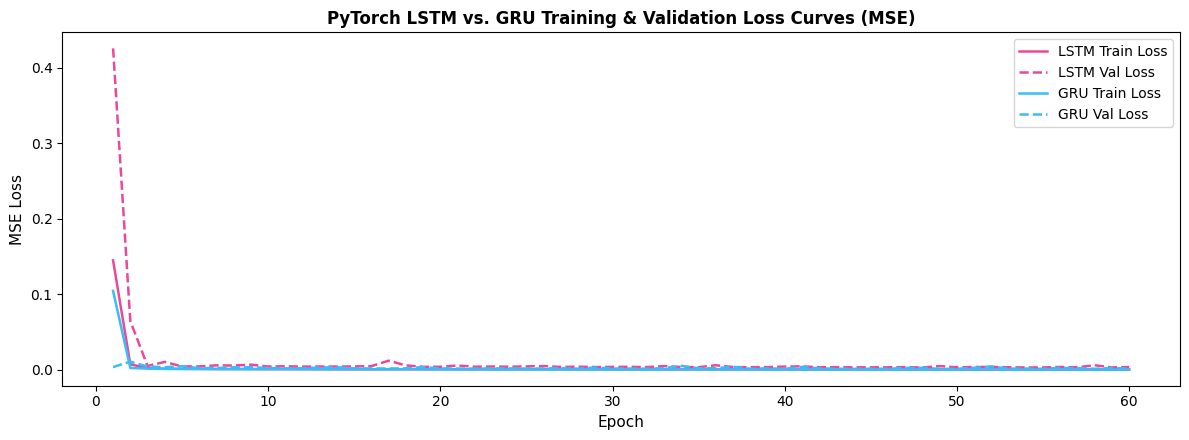

In [ ]:
epochs_range = range(1, 61)

plt.figure(figsize=(12, 4.5))
plt.plot(epochs_range, lstm_train_loss, label='LSTM Train Loss', color='#EC4899', linewidth=1.8)
plt.plot(epochs_range, lstm_val_loss, label='LSTM Val Loss', color='#EC4899', linestyle='--', linewidth=1.8)
plt.plot(epochs_range, gru_train_loss, label='GRU Train Loss', color='#38BDF8', linewidth=1.8)
plt.plot(epochs_range, gru_val_loss, label='GRU Val Loss', color='#38BDF8', linestyle='--', linewidth=1.8)
plt.title('PyTorch LSTM vs. GRU Training & Validation Loss Curves (MSE)', fontsize=12, fontweight='bold')
plt.xlabel('Epoch', fontsize=11)
plt.ylabel('MSE Loss', fontsize=11)
plt.legend()
plt.tight_layout()
plt.show()

## 6. Model Evaluation & Benchmark Comparison
Generating predictions on unseen test set, inverse transforming scaled values back to real USD prices, and computing error metrics (MSE, RMSE, MAE).
We include a **20-day Simple Moving Average (SMA-20)** and a **1-Day Lag Model** as naive baselines.

In [ ]:
lstm_model.eval()
gru_model.eval()

with torch.no_grad():
    lstm_preds_scaled = lstm_model(X_test).numpy()
    gru_preds_scaled = gru_model(X_test).numpy()

# Inverse transform predictions and actual targets
actual_prices = scaler.inverse_transform(y_test.numpy()).flatten()
lstm_preds = scaler.inverse_transform(lstm_preds_scaled).flatten()
gru_preds = scaler.inverse_transform(gru_preds_scaled).flatten()

# Naive Baselines
sma_preds = scaler.inverse_transform(X_test[:, -1, 0].numpy().reshape(-1, 1)).flatten()
lag1_preds = np.roll(actual_prices, 1)
lag1_preds[0] = actual_prices[0]

def get_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    return mse, rmse, mae

lstm_mse, lstm_rmse, lstm_mae = get_metrics(actual_prices, lstm_preds)
gru_mse, gru_rmse, gru_mae = get_metrics(actual_prices, gru_preds)
sma_mse, sma_rmse, sma_mae = get_metrics(actual_prices, sma_preds)
lag1_mse, lag1_rmse, lag1_mae = get_metrics(actual_prices, lag1_preds)

results_df = pd.DataFrame({
    'Model': ['GRU Model (PyTorch)', 'LSTM Model (PyTorch)', 'Baseline (SMA-20)', 'Baseline (1-Day Lag)'],
    'RMSE ($)': [f'${gru_rmse:.2f}', f'${lstm_rmse:.2f}', f'${sma_rmse:.2f}', f'${lag1_rmse:.2f}'],
    'MSE': [f'{gru_mse:.2f}', f'{lstm_mse:.2f}', f'{sma_mse:.2f}', f'{lag1_mse:.2f}'],
    'MAE ($)': [f'${gru_mae:.2f}', f'${lstm_mae:.2f}', f'${sma_mae:.2f}', f'${lag1_mae:.2f}'],
    'Train Time (s)': [f'{gru_time:.2f}s', f'{lstm_time:.2f}s', '0.00s', '0.00s']
})

results_df

Model,RMSE ($),MSE,MAE ($),Train Time (s)
GRU Model (PyTorch),$4.24,18.01,$3.24,33.57s
LSTM Model (PyTorch),$5.95,35.38,$4.55,15.59s
Baseline (SMA-20),$3.18,10.13,$2.31,0.00s
Baseline (1-Day Lag),$3.18,10.13,$2.31,0.00s


### 6.1 Test Set Predictions Plot
Visualizing model predictions against actual AMZN closing prices over the test period.

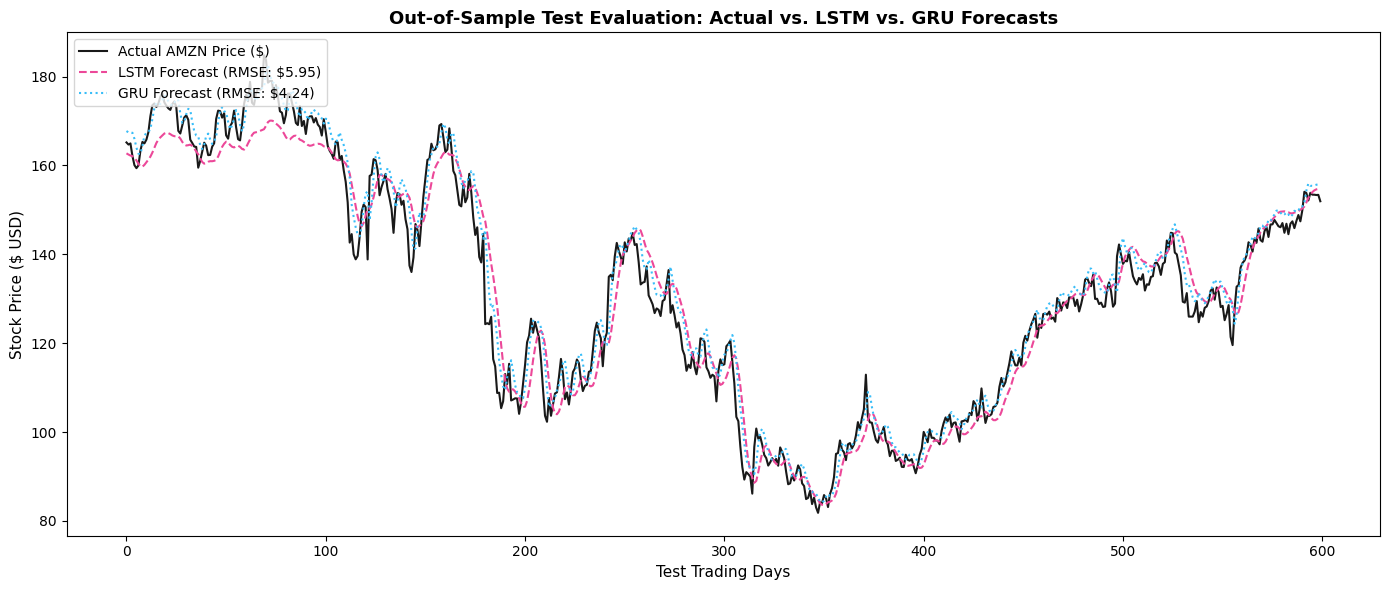

In [ ]:
plt.figure(figsize=(14, 6))
plt.plot(actual_prices, label='Actual AMZN Price ($)', color='black', linewidth=1.5, alpha=0.9)
plt.plot(lstm_preds, label=f'LSTM Forecast (RMSE: ${lstm_rmse:.2f})', color='#EC4899', linewidth=1.5, linestyle='--')
plt.plot(gru_preds, label=f'GRU Forecast (RMSE: ${gru_rmse:.2f})', color='#38BDF8', linewidth=1.5, linestyle=':')

plt.title('Out-of-Sample Test Evaluation: Actual vs. LSTM vs. GRU Forecasts', fontsize=13, fontweight='bold')
plt.xlabel('Test Trading Days', fontsize=11)
plt.ylabel('Stock Price ($ USD)', fontsize=11)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

### 6.2 Zoomed-in 100-Day Window & Lag Effect Inspection
Inspecting a 100-day window to evaluate whether predictions lag behind price spikes or genuinely forecast directional changes.

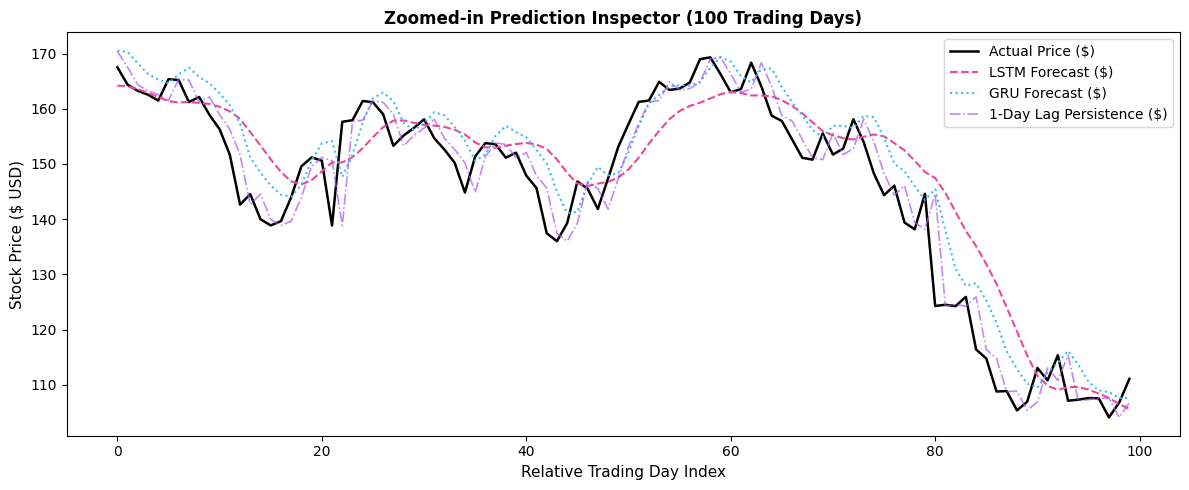

In [ ]:
window_slice = slice(100, 200)

plt.figure(figsize=(12, 5))
plt.plot(actual_prices[window_slice], label='Actual Price ($)', color='black', linewidth=1.8)
plt.plot(lstm_preds[window_slice], label='LSTM Forecast ($)', color='#EC4899', linewidth=1.5, linestyle='--')
plt.plot(gru_preds[window_slice], label='GRU Forecast ($)', color='#38BDF8', linewidth=1.5, linestyle=':')
plt.plot(lag1_preds[window_slice], label='1-Day Lag Persistence ($)', color='#A855F7', linewidth=1.2, linestyle='-.', alpha=0.7)

plt.title('Zoomed-in Prediction Inspector (100 Trading Days)', fontsize=12, fontweight='bold')
plt.xlabel('Relative Trading Day Index', fontsize=11)
plt.ylabel('Stock Price ($ USD)', fontsize=11)
plt.legend()
plt.tight_layout()
plt.show()

## 7. AI Ethics & Critical Perspective ("AI Snake Oil")
Evaluating model behavior under critical machine learning principles (Narayanan & Kapoor, Princeton University):

1. **Market Stochasticity:** Stock price time series contain high levels of non-stationary noise. Historical price sequences alone cannot predict external events like macroeconomic policy shifts or quarterly earnings surprises.
2. **Lag Effect Illusion:** Sequential models (LSTM/GRU) trained on historical price targets often exhibit a 1-day lag effect—predicting tomorrow's price as close to today's price. While this minimizes MSE/RMSE, it does not guarantee profitable directional accuracy.
3. **Responsible AI Deployment:** Machine learning outputs in financial contexts must serve as decision-support tools rather than deterministic investment advice, requiring strict risk management.